In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
bus_normal = pd.read_csv('2025_arrival_records_merge_normal.csv', low_memory=False)
bus_grandprix = pd.read_csv('2025_arrival_records_merge_grandprix.csv', low_memory=False)

In [3]:
bus_normal['hour'] = pd.to_datetime(bus_normal['time'], format='%H:%M:%S').dt.hour 
bus_grandprix['hour'] = pd.to_datetime(bus_grandprix['time'], format='%H:%M:%S').dt.hour

In [4]:
combined = pd.concat([bus_normal[['endStation']], bus_grandprix[['endStation']]], ignore_index=True)
_, unique_values = pd.factorize(combined['endStation'])
value_to_code = {val: code for code, val in enumerate(unique_values)}
bus_normal['endStation'] = bus_normal['endStation'].map(value_to_code)
bus_grandprix['endStation'] = bus_grandprix['endStation'].map(value_to_code)

In [5]:
bus_normal

,route,startStation,endStation,time,weekday,passengerFlow,trafficCondition,busPlate,passbyNum,weather,arrivalDuration,hour
0,15,T336/2,0,5:30:56,6,-1,1,AB5425,0,1,20,5
1,15,T335,1,5:31:16,6,-1,1,AB5425,0,1,10,5
2,15,T338,2,5:32:17,6,-1,-1,AB5425,0,1,50,5
3,15,T326/3,3,5:33:08,6,-1,1,AB5425,0,1,40,5
4,15,T332/2,4,5:34:39,6,-1,1,AB5425,0,1,50,5
...,...,...,...,...,...,...,...,...,...,...,...,...
161336,AP1,T343,157,1:54:54,6,-1,1,AA7392,0,2,355,1
161337,AP1,M239/1,152,1:55:55,6,-1,1,AA7392,0,2,20,1
161338,AP1,M254,158,1:59:58,6,-1,2,AA7392,12,2,203,1
161339,AP1,M64,139,2:03:54,6,-1,1,AA7392,1,2,205,2


In [6]:
selected_feature = ['endStation', 'hour','weekday', 'passengerFlow', 'trafficCondition', 'weather', 'arrivalDuration']
bus_normal = bus_normal[selected_feature]
bus_grandprix = bus_grandprix[selected_feature]
bus_normal

,endStation,hour,weekday,passengerFlow,trafficCondition,weather,arrivalDuration
0,0,5,6,-1,1,1,20
1,1,5,6,-1,1,1,10
2,2,5,6,-1,-1,1,50
3,3,5,6,-1,1,1,40
4,4,5,6,-1,1,1,50
...,...,...,...,...,...,...,...
161336,157,1,6,-1,1,2,355
161337,152,1,6,-1,1,2,20
161338,158,1,6,-1,2,2,203
161339,139,2,6,-1,1,2,205


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()
bus_normal = scaler.fit_transform(bus_normal)
bus_grandprix = scaler.transform(bus_grandprix)

In [9]:
pca_normal = PCA()
pca_normal.fit(bus_normal)
pca_grandprix = PCA()
pca_grandprix.fit(bus_grandprix)

PCA()

In [10]:
print("Explained variance ratio per component:", pca_normal.explained_variance_ratio_)
cumulative_variance_ratio = np.cumsum(pca_normal.explained_variance_ratio_)
print("Cumulative explained variance ratio:", cumulative_variance_ratio)

Explained variance ratio per component: [0.19766259 0.18241424 0.15566776 0.14341532 0.11869678 0.10343471
 0.0987086 ]
Cumulative explained variance ratio: [0.19766259 0.38007683 0.53574459 0.67915991 0.79785669 0.9012914
 1.        ]


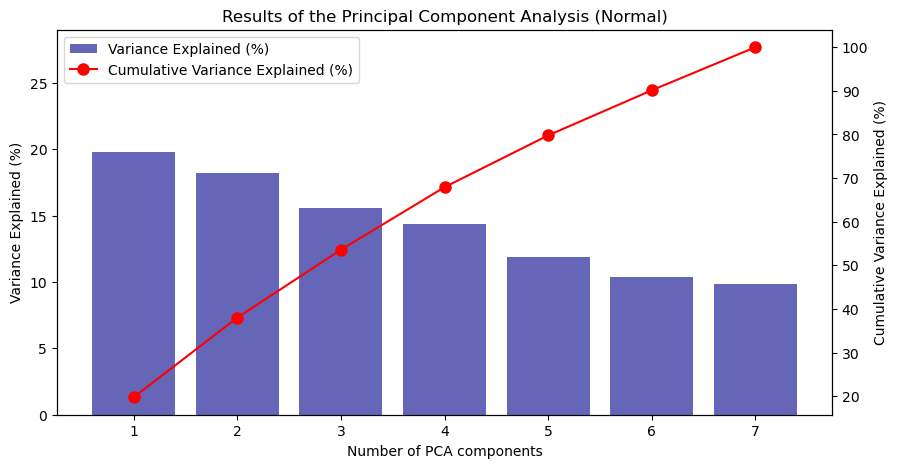

In [11]:
var_exp = pca_normal.explained_variance_ratio_ * 100
cum_var_exp = np.cumsum(var_exp)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, align='center', color='darkblue', label='Variance Explained (%)')
ax1.set_ylim(0, 29)

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, 'r-o', markersize=8, label='Cumulative Variance Explained (%)')

ax1.set_xlabel('Number of PCA components')
ax1.set_ylabel('Variance Explained (%)')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax1.set_xticks(range(1, len(var_exp) + 1))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.title('Results of the Principal Component Analysis (Normal)')
plt.show()

In [12]:
print("Explained variance ratio per component:", pca_grandprix.explained_variance_ratio_)
cumulative_variance_ratio = np.cumsum(pca_grandprix.explained_variance_ratio_)
print("Cumulative explained variance ratio:", cumulative_variance_ratio)

Explained variance ratio per component: [0.25496089 0.19782423 0.1831211  0.14660863 0.10699607 0.07882872
 0.03166036]
Cumulative explained variance ratio: [0.25496089 0.45278511 0.63590622 0.78251485 0.88951092 0.96833964
 1.        ]


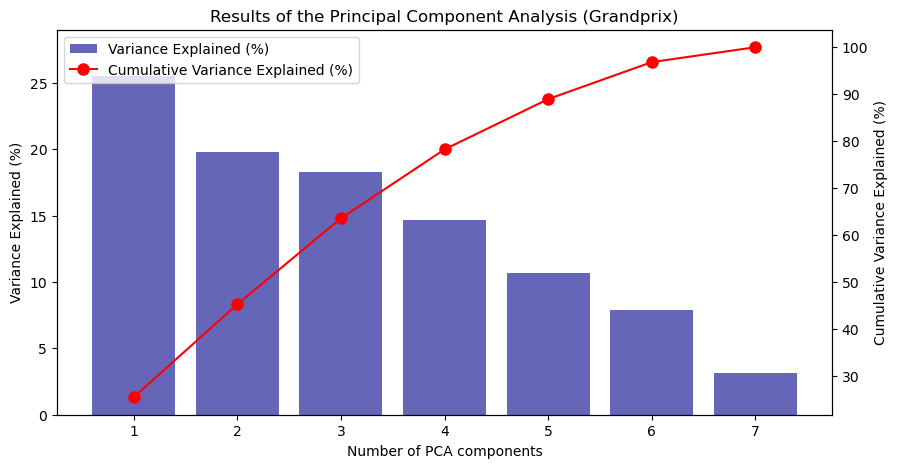

In [13]:
var_exp = pca_grandprix.explained_variance_ratio_ * 100
cum_var_exp = np.cumsum(var_exp)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, align='center', color='darkblue', label='Variance Explained (%)')
ax1.set_ylim(0, 29)

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, 'r-o', markersize=8, label='Cumulative Variance Explained (%)')

ax1.set_xlabel('Number of PCA components')
ax1.set_ylabel('Variance Explained (%)')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax1.set_xticks(range(1, len(var_exp) + 1))

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.title('Results of the Principal Component Analysis (Grandprix)')
plt.show()

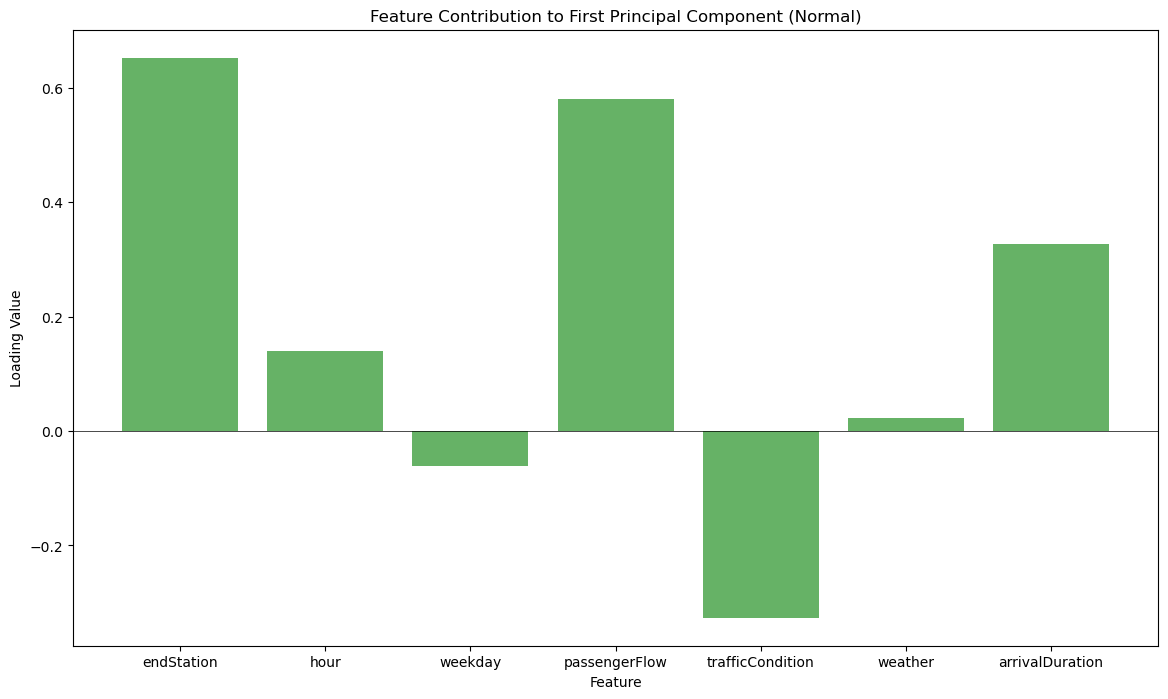

In [14]:
pc_normal = pca_normal.transform(bus_normal)
loadings_normal = pd.DataFrame(pca_normal.components_.T, columns=[f'PC{i+1}' for i in range(len(selected_feature))], index=selected_feature)

plt.figure(figsize=(14, 8))
plt.bar(loadings_normal.index, loadings_normal['PC1'], alpha=0.6, color='green')
plt.axhline(0, color='k', linewidth=0.5)
plt.title('Feature Contribution to First Principal Component (Normal)')
plt.xlabel('Feature')
plt.ylabel('Loading Value')
plt.show()

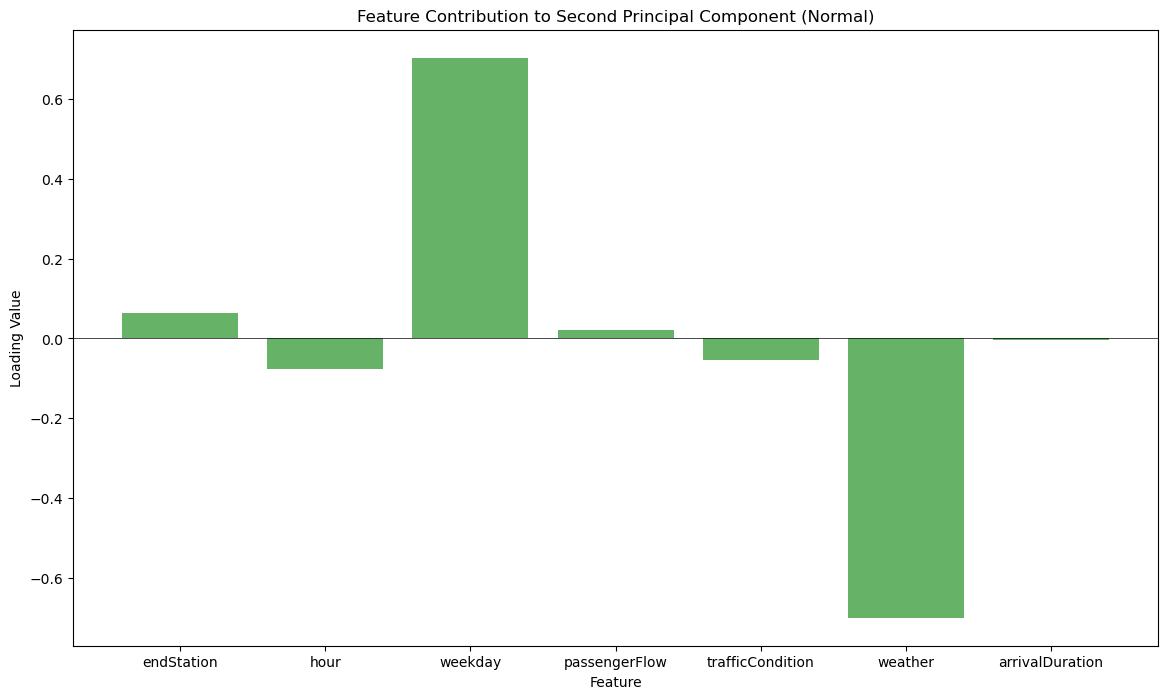

In [15]:
plt.figure(figsize=(14, 8))
plt.bar(loadings_normal.index, loadings_normal['PC2'], alpha=0.6, color='green')
plt.axhline(0, color='k', linewidth=0.5)
plt.title('Feature Contribution to Second Principal Component (Normal)')
plt.xlabel('Feature')
plt.ylabel('Loading Value')
plt.show()

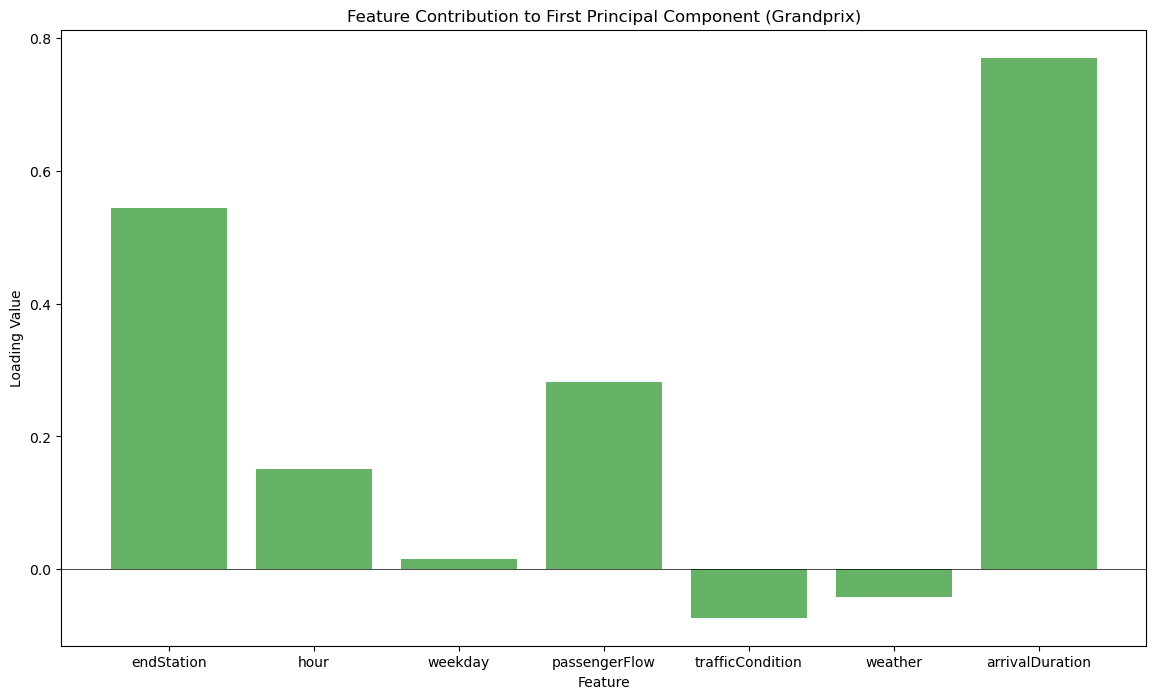

In [16]:
pc_grandprix = pca_grandprix.transform(bus_grandprix)
loadings_grandprix = pd.DataFrame(pca_grandprix.components_.T, columns=[f'PC{i+1}' for i in range(len(selected_feature))], index=selected_feature)

plt.figure(figsize=(14, 8))
plt.bar(loadings_grandprix.index, loadings_grandprix['PC1'], alpha=0.6, color='green')
plt.axhline(0, color='k', linewidth=0.5)
plt.title('Feature Contribution to First Principal Component (Grandprix)')
plt.xlabel('Feature')
plt.ylabel('Loading Value')
plt.show()

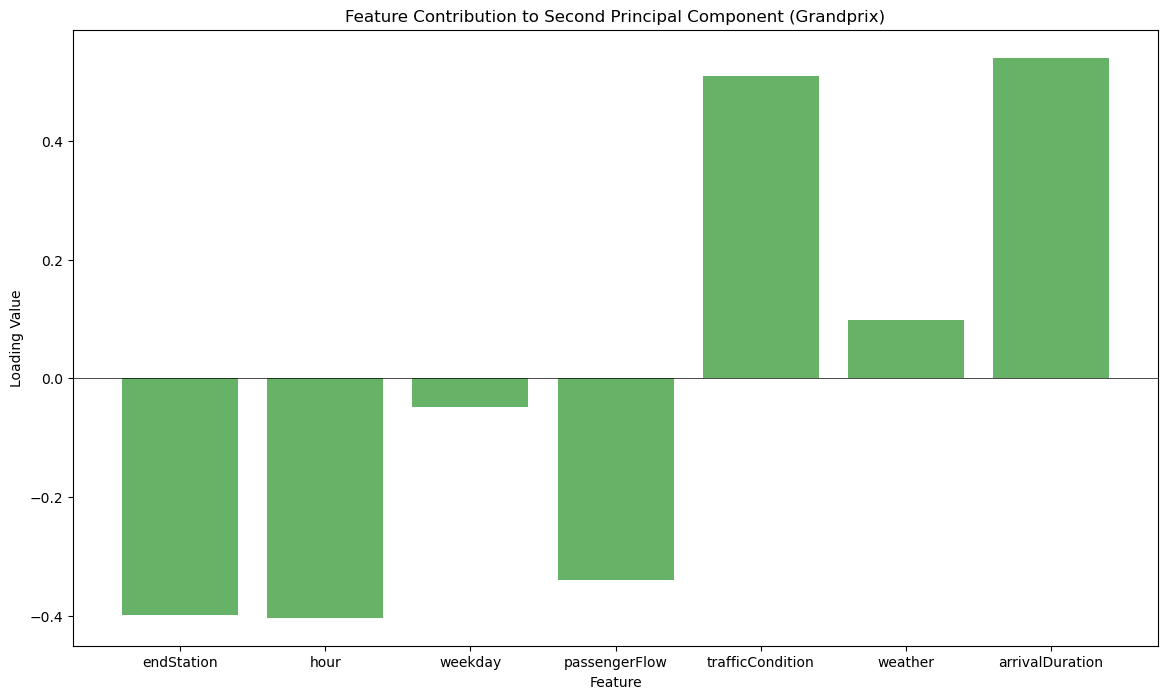

In [17]:
plt.figure(figsize=(14, 8))
plt.bar(loadings_grandprix.index, loadings_grandprix['PC2'], alpha=0.6, color='green')
plt.axhline(0, color='k', linewidth=0.5)
plt.title('Feature Contribution to Second Principal Component (Grandprix)')
plt.xlabel('Feature')
plt.ylabel('Loading Value')
plt.show()

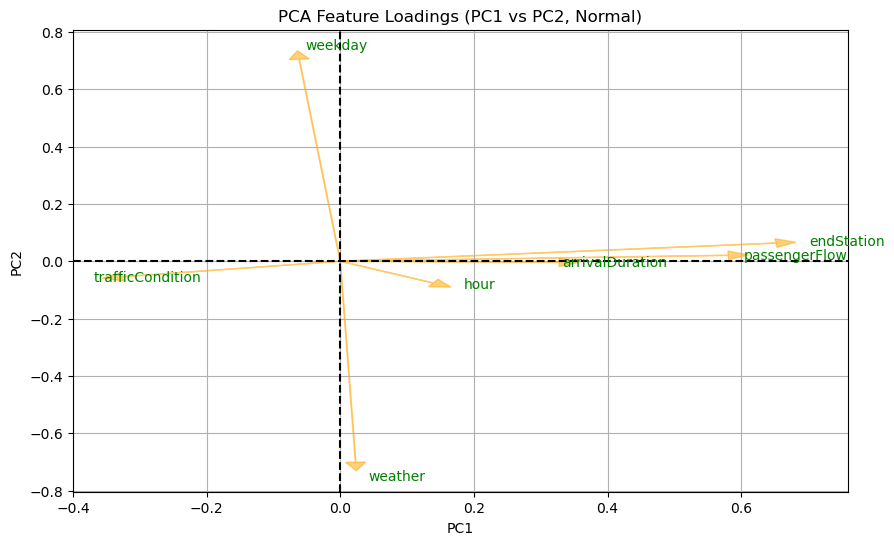

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(selected_feature)):
    ax.arrow(0, 0, loadings_normal.loc[selected_feature[i], 'PC1'], loadings_normal.loc[selected_feature[i], 'PC2'],
             head_width=0.03, head_length=0.03, color='orange', alpha=0.5)
    ax.text(loadings_normal.loc[selected_feature[i], 'PC1'] * 1.07 + 0.06, loadings_normal.loc[selected_feature[i], 'PC2'] * 1.07,
            selected_feature[i], color='g', ha='center', va='center')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_xlim(-0.4, 0.76)
ax.axvline(0, color='k', linestyle='--')
ax.axhline(0, color='k', linestyle='--')
ax.grid()
plt.title('PCA Feature Loadings (PC1 vs PC2, Normal)')
plt.show()

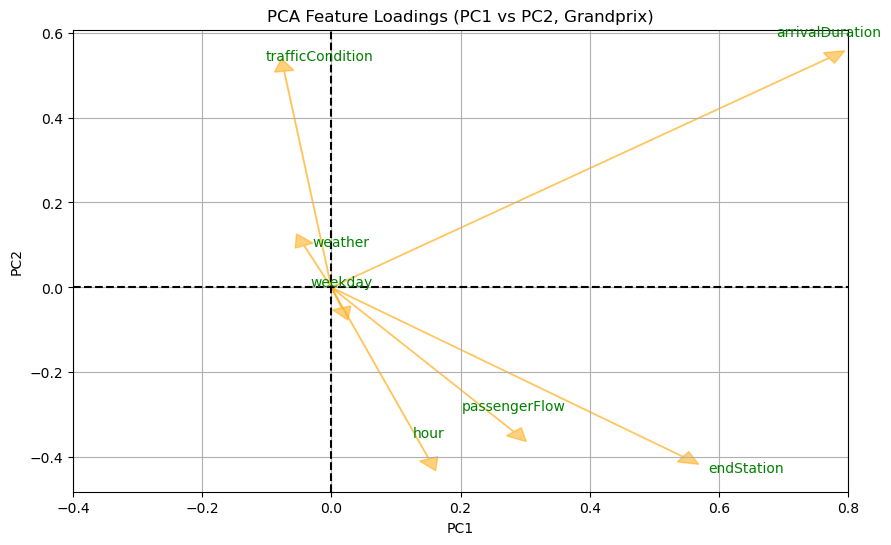

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(selected_feature)):
    ax.arrow(0, 0, loadings_grandprix.loc[selected_feature[i], 'PC1'], loadings_grandprix.loc[selected_feature[i], 'PC2'],
             head_width=0.03, head_length=0.03, color='orange', alpha=0.5)
    if (selected_feature[i] == 'arrivalDuration') | (selected_feature[i] == 'passengerFlow'):
        ax.text(loadings_grandprix.loc[selected_feature[i], 'PC1'], loadings_grandprix.loc[selected_feature[i], 'PC2'] + 0.06,
            selected_feature[i], color='g', ha='center', va='center')
        continue
    if (selected_feature[i] == 'hour') | (selected_feature[i] == 'weekday'):
        ax.text(loadings_grandprix.loc[selected_feature[i], 'PC1'], loadings_grandprix.loc[selected_feature[i], 'PC2'] + 0.06,
            selected_feature[i], color='g', ha='center', va='center')
        continue
    ax.text(loadings_grandprix.loc[selected_feature[i], 'PC1'] * 1.07 + 0.06, loadings_grandprix.loc[selected_feature[i], 'PC2'] * 1.07,
            selected_feature[i], color='g', ha='center', va='center')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_xlim(-0.4, 0.8)
ax.axvline(0, color='k', linestyle='--')
ax.axhline(0, color='k', linestyle='--')
ax.grid()
plt.title('PCA Feature Loadings (PC1 vs PC2, Grandprix)')
plt.show()